# **Image Stitching & Panoramas**

## **Objectives:**
1. See what `cv2.Stitcher` does under the hood — the same feature-matching pipeline as notebook 27, applied photo-to-photo instead of object-to-scene
2. Stitch three overlapping shots into one panorama with the high-level API
3. Understand *why* stitching needs more than just feature matching — warping, seam finding, and exposure blending

> **Assets.** `assets/images/pano_left.jpg`, `pano_mid.jpg`, `pano_right.jpg` are three overlapping "camera positions" derived from `assets/images/home.jpg` (an OpenCV official sample photo, [Apache 2.0](https://github.com/opencv/opencv/tree/4.x/samples/data)) — see `scripts/generate_assets.py` for exactly how. Real, clearly-licensed *overlapping-photo sets* turn out to be surprisingly hard to find bundled anywhere at redistribution-safe terms — `opencv_extra`'s own stitching test data, for instance, ships with no LICENSE file at all — so these three tiles are instead cropped from one real photo with mild independent perspective jitter and brightness/contrast shifts applied to each. That's enough genuine baseline for `cv2.Stitcher` to do real feature matching, homography estimation, warping, and blending — not just paste pixels back together.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

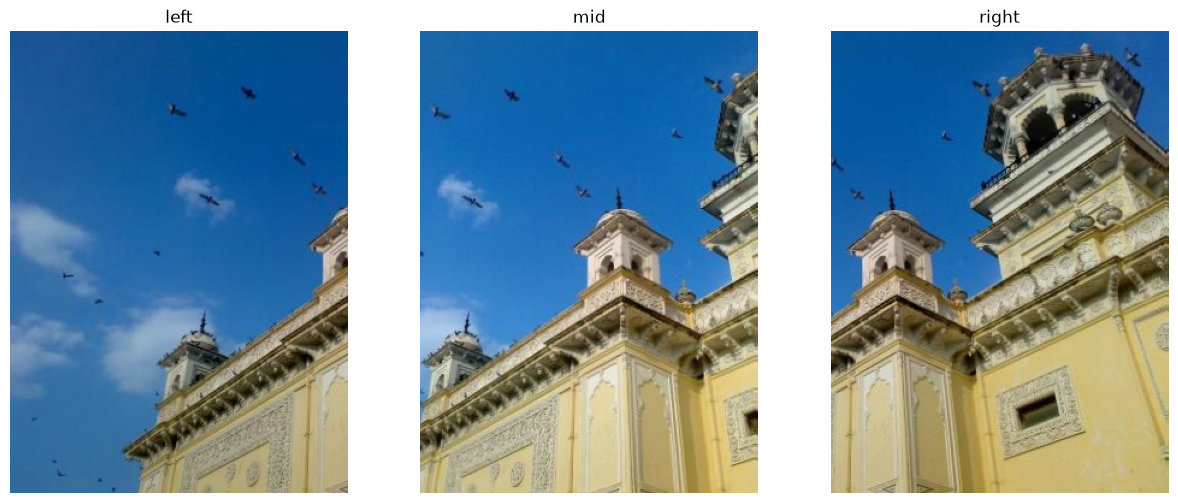

In [2]:
left = cv2.imread('assets/images/pano_left.jpg')
mid = cv2.imread('assets/images/pano_mid.jpg')
right = cv2.imread('assets/images/pano_right.jpg')

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax, img, title in zip(axes, [left, mid, right], ['left', 'mid', 'right']):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.show()

## **Why stitching is more than "find matches, warp, done"**

Notebook 27's pipeline — detect keypoints, match descriptors, RANSAC a homography — gets you *most* of the way to a panorama, but three more problems show up once you're blending whole photos instead of drawing one outline:

1. **Bundle adjustment.** With 3+ images, pairwise homographies (A→B, B→C) accumulate error — `cv2.Stitcher` jointly refines every image's pose at once so the whole panorama is globally consistent, not just locally consistent pair by pair.
2. **Seam finding.** Where two warped images overlap, which pixel wins? A hard cut down the middle of the overlap creates a visible seam wherever content doesn't align perfectly (our synthetic jitter guarantees it won't) — a seam finder looks for a cut that follows *low-contrast, low-difference* pixels instead of a straight line.
3. **Exposure compensation.** Our three tiles were deliberately given different brightness/contrast (simulating different camera exposures) — blended naively, the panorama would show visible brightness bands at every seam. `cv2.Stitcher` estimates a per-image gain to even this out before blending.

`cv2.Stitcher_create()` runs all of this as one pipeline — the cells below call it directly, then peek at a couple of the intermediate stages separately, using the exact same detector/matcher classes from notebook 27.

Stitcher status: OK


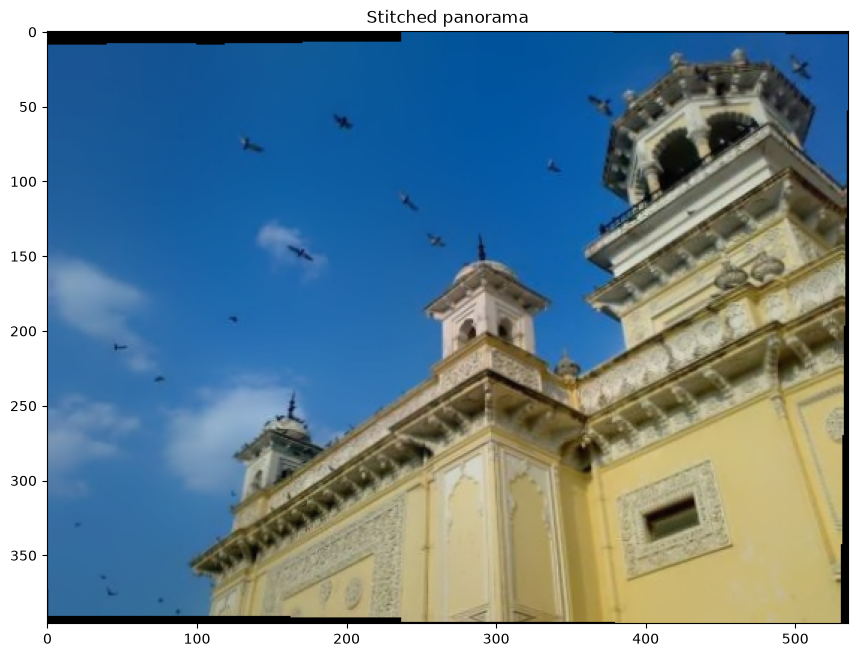

In [3]:
stitcher = cv2.Stitcher_create()
status, panorama = stitcher.stitch([left, mid, right])

status_names = {
    cv2.Stitcher_OK: 'OK',
    cv2.Stitcher_ERR_NEED_MORE_IMGS: 'ERR_NEED_MORE_IMGS (not enough overlap/features)',
    cv2.Stitcher_ERR_HOMOGRAPHY_EST_FAIL: 'ERR_HOMOGRAPHY_EST_FAIL',
    cv2.Stitcher_ERR_CAMERA_PARAMS_ADJUST_FAIL: 'ERR_CAMERA_PARAMS_ADJUST_FAIL',
}
print('Stitcher status:', status_names.get(status, status))

if status == cv2.Stitcher_OK:
    imshow('Stitched panorama', panorama, size=14)
else:
    raise RuntimeError(f'Stitching failed with status {status}')

## **Peeking at the matching stage manually**

`cv2.Stitcher` hides its internals behind one call — here's the same detect-and-match step from notebook 27, run directly on the left/mid pair, to confirm there's nothing magic happening: it's SIFT keypoints and ratio-tested matches, same as before, just feeding a warping+blending pipeline instead of a single outline.

left/mid: 306/649 keypoints, 181 good matches — this is exactly what cv2.Stitcher does internally for every image pair.


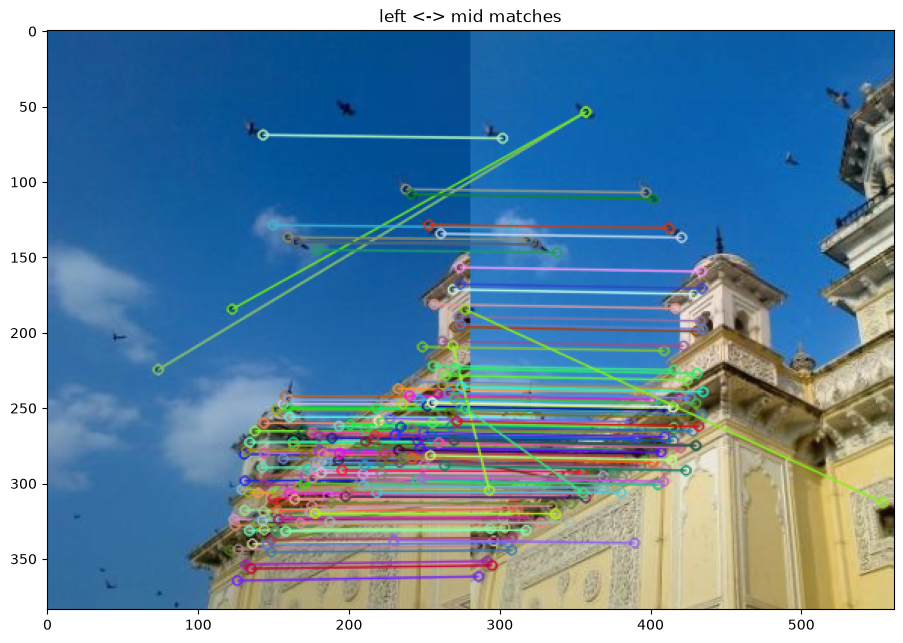

In [4]:
left_gray = cv2.cvtColor(left, cv2.COLOR_BGR2GRAY)
mid_gray = cv2.cvtColor(mid, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(left_gray, None)
kp2, des2 = sift.detectAndCompute(mid_gray, None)

bf = cv2.BFMatcher()
knn_matches = bf.knnMatch(des1, des2, k=2)
good = [m for m, n in knn_matches if m.distance < 0.75 * n.distance]
print(f'left/mid: {len(kp1)}/{len(kp2)} keypoints, {len(good)} good matches — '
      f'this is exactly what cv2.Stitcher does internally for every image pair.')

match_vis = cv2.drawMatches(left, kp1, mid, kp2, good, None,
                              flags=cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS)
imshow('left <-> mid matches', match_vis, size=16)

### A couple of directions to take this

- Crop the black, irregular border `cv2.Stitcher` leaves behind: threshold the panorama to find its largest inscribed rectangle (or just eyeball-crop it) for a clean final image.
- Try `cv2.Stitcher_create(cv2.Stitcher_SCANS)` instead of the default `PANORAMA` mode — it skips perspective warping in favor of a simpler planar model, which suits flat documents/scans (notebook 18) better than wide-baseline photos.
- Regenerate the panorama tiles with more aggressive jitter in `scripts/generate_assets.py` (bigger `shift`, wider brightness range) until `cv2.Stitcher` actually fails — seeing *where* it breaks is as instructive as seeing it work.